This is the first application built with the camera / labeling / inference system.

Guided by lessons 1 and 2 of the fast.ai [Practical Deep Learning for Coders](https://course.fast.ai) course, we will train a model to detect whether a baby gate in sight of the camera is closed or open.

## Labeling

The porch labeling config for this application is
```
{
    "tagSets": [
        {
            "name": "gate_openness",
            "tags": ["gate_open", "gate_closed"]
        }
    ]
}
```

For each `{}.jpg` file, we need to look for a matching `{}.labels.json` file (produced by the labeling UI) and find these tags in it.

In [3]:
path = "/tmp/porch/images/"

import json
import os

def is_gate_open(jpg_file_name: str) -> bool | None:
    label_file_name = jpg_file_name[:-4] + ".labels.json"
    try:
        with open(os.path.join(path, label_file_name)) as f:
            labels = json.load(f)
        tags = [ts["tags"] for ts in labels["tagSets"] if ts["name"] == "gate_openness"]
        if len(tags) == 0:
            return None
        if "gate_closed" in tags[0]:
            return False
        if "gate_open" in tags[0]:
            return True
        return None
    except:
        return None

# Test that it finds these labels successfully
files = os.listdir(path)
labels = [is_gate_open(f) for f in files if f.endswith(".jpg")]
assert True in labels
assert False in labels

Next we get the images into the fastai data loader.

Found 2151 labeled images


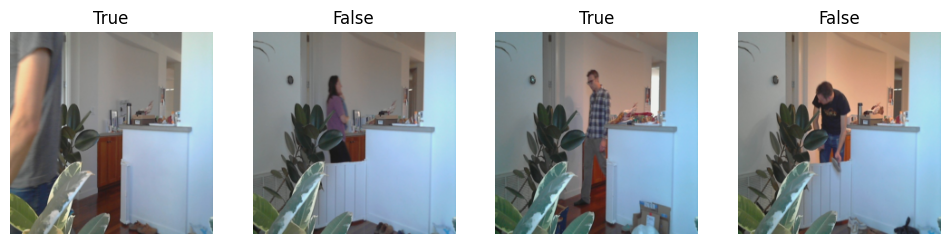

In [32]:
from fastai.vision.all import *

def images_with_labels(path):
    images = get_image_files(path)
    valid = [i for i in images if i.name.endswith(".jpg") and is_gate_open(i.name) is not None]
    print(f"Found {len(valid)} labeled images")
    return valid

dls = ImageDataLoaders.from_name_func(
    path,
    images_with_labels(path),
    valid_pct=0.2,
    seed=2025,
    label_func=is_gate_open,
    item_tfms=Resize(224, ResizeMethod.Squish))

dls.valid.show_batch(max_n=4, nrows=1)

At this point we can actually train a model.

Here we start with the resnet18 foundation model, which apparently is seeded with knowledge of some fundamental image properties like colors, shapes, and edge detection.

This step runs in a little less than 1 minute on my 2024 M4 MacBook Pro.

In [28]:
learn18 = vision_learner(dls, resnet18, metrics=error_rate)
learn18.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.515025,0.052724,0.013953,00:10


epoch,train_loss,valid_loss,error_rate,time
0,0.043785,0.000946,0.000000,00:12
1,0.022977,0.000853,0.000000,00:12
2,0.013054,0.001964,0.000000,00:12


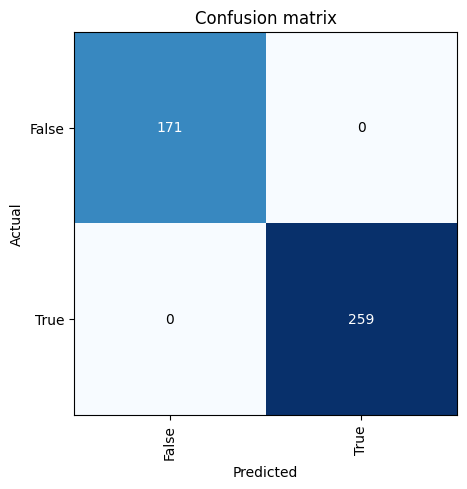

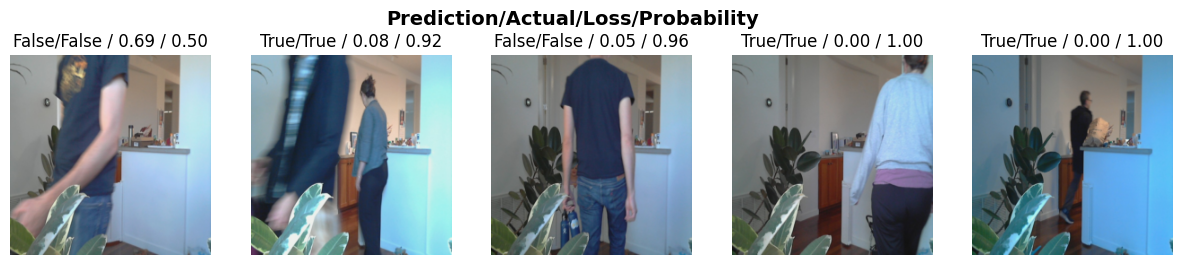

In [34]:
interp18 = ClassificationInterpretation.from_learner(learn18)
interp18.plot_confusion_matrix()

interp18.plot_top_losses(5, nrows=1)

The model looks good, with 99% accuracy.

Some of the ambiguous ones seem to be cases where we are occluding the gate to some degree, which makes sense.

## Exporting a portable model

So far this is all in Python running on my laptop, but next I want to run the model on the camera device during frame capture.

The FastAI learner uses a PyTorch model internally. We can use the PyTorch tools to [export it to the ONNX format](https://github.com/onnx/tutorials/blob/main/tutorials/PytorchOnnxExport.ipynb). This will allow us to use other inference runtimes to run the model.

In [ ]:
onnx_file_path = "/tmp/porch/models/gate_openness_20251101.onnx"

import os
# Make sure the directory exists
os.makedirs(os.path.dirname(onnx_file_path), exist_ok=True)

# pip install torch, onnx, onnxscript
import torch

dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    # learn34.model is a PyTorch model
    learn18.model.cpu(),
    dummy_input,
    onnx_file_path,
    # dynamo=True, # "always_classified is unsupported", maybe a fastai incompatibility?
)

# If not using dynamo, verify model integrity ourselves
import onnx
round_trip_model = onnx.load(onnx_file_path)
onnx.checker.check_model(round_trip_model, full_check = True)

/var/folders/5_/zdtnjt8d5lz8hcpjh651l6380000gn/T/ipykernel_19126/2223916030.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


At this point we would be wise to double check the round-tripped model against the original.

We can do this by running the models against a couple test images and comparing the outputs.

Since we will be evaluating the serialized model outside of fastai, we first need to figure out how to load it into a tensor, meaning the array of data that serves as input to the model.

Manually writing out the PIL image incantation for loading an image into a tensor (otherwise buried in the fastai / PyTorch code) can also help us validate that we know how to prepare the image input tensor, which we will have to replicate on the device using other image manipulation libraries.

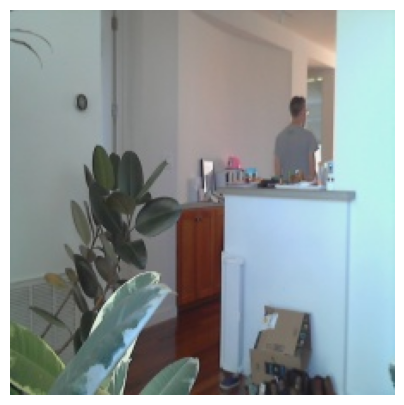

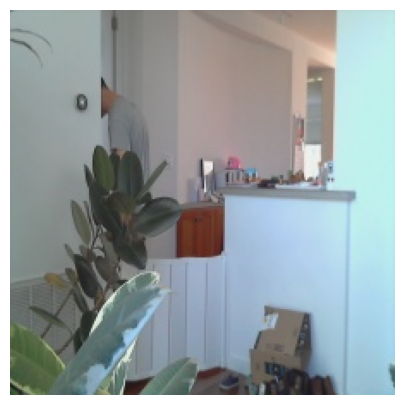

In [38]:
# Images from the training set, already resized to 224x224
open_image = PILImage.create(f"{path}/2025-10-31_21-57-52-100_+0000.224.jpg")
closed_image = PILImage.create(f"{path}/2025-10-31_21-57-42-852_+0000.224.jpg")

open_image.show()
closed_image.show()

# pip install torchvision
from torchvision import transforms
def pil_to_tensor(pil_image):
    tfms = transforms.Compose([transforms.ToTensor()])
    tensor = tfms(pil_image).unsqueeze(0)
    tensor = tensor.to("cpu")
    return tensor

open_image_tensor = pil_to_tensor(open_image)
closed_image_tensor = pil_to_tensor(closed_image)

assert open_image_tensor.shape == (1, 3, 224, 224)
assert closed_image_tensor.shape == (1, 3, 224, 224)

Now that we have those images, we can load the onnx model and run it.

In [39]:
# pip install onnx2torch
import onnx2torch

round_trip_pytorch_model = onnx2torch.convert(round_trip_model)
round_trip_pytorch_model.eval()
round_trip_pytorch_model.to("cpu")

with torch.no_grad():
    onnx_open_output = round_trip_pytorch_model(open_image_tensor)
    print(f"onnx open result:   {onnx_open_output}")

with torch.no_grad():
    onnx_closed_output = round_trip_pytorch_model(closed_image_tensor)
    print(f"onnx closed result: {onnx_closed_output}")

onnx open result:   tensor([[-1.1226, -0.0198]])
onnx closed result: tensor([[ 0.5798, -1.3870]])


And we can compare these inputs to the original model trained by fastai.

In [40]:
learn18.model.eval()
learn18.model.to("cpu")

with torch.no_grad():
    fastai_open_output = learn18.model(open_image_tensor)
    print(f"learner open result:   {fastai_open_output}")

with torch.no_grad():
    fastai_closed_output = learn18.model(closed_image_tensor)
    print(f"learner closed result: {fastai_closed_output}")

learner open result:   tensor([[-1.1226, -0.0198]])
learner closed result: tensor([[ 0.5798, -1.3870]])


Looks good!

Here's another test run using `onnxruntime` directly, which is the library we are going to use on device, rather than importing it back into pytorch.

In [43]:
# pip install onnxruntime
import onnxruntime as ort

session = ort.InferenceSession(onnx_file_path)

input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape

output_names = [output.name for output in session.get_outputs()]

ort_open_results = session.run(output_names, {input_name: open_image_tensor.numpy()})
print(f"ort open result:   {ort_open_results}")

ort_closed_results = session.run(output_names, {input_name: closed_image_tensor.numpy()})
print(f"ort closed result:   {ort_closed_results}")

ort open result:   [array([[-1.1225896 , -0.01975971]], dtype=float32)]
ort closed result:   [array([[ 0.5798145, -1.3869997]], dtype=float32)]


Looks like a close match for the PyTorch version!

What do these numbers actually mean?

This model is a classifier, and the two-element array are apparently "logits" representing the scores that the model gives to each of the two categories, which in this case can be labeled as
```
["gate_closed", "gate_open"]
```

The `softmax` function is used to normalize these scores to probabilities for each category.

In [46]:
torch.nn.functional.softmax(onnx_closed_output, dim=1)

tensor([[0.8773, 0.1227]])